# Survey Response Analysis

This notebook loads the saved survey responses, aggregates results across all cases, and presents them as tables and charts.

It focuses on three output views:

- numeric ratings such as `q1`
- categorical comparison answers such as `q4`
- open-ended responses such as `q2`, `q3`, and `q5`

## 1. Load Input Data

Import the required libraries and locate the response file in a way that works whether the notebook is started from the repository root or the `eval` directory.

In [6]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import display


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return current


repo_root = find_repo_root()
response_candidates = [
    repo_root / "eval" / "survey-responces.json",
    repo_root / "survey-responces.json",
    Path.cwd() / "survey-responces.json",
]
responses_path = next((path for path in response_candidates if path.exists()), None)
if responses_path is None:
    raise FileNotFoundError("Could not find eval/survey-responces.json")

survey_candidates = [
    repo_root / "eval" / "output" / "survey.json",
    repo_root / "output" / "survey.json",
    Path.cwd() / "output" / "survey.json",
]
survey_path = next((path for path in survey_candidates if path.exists()), None)
if survey_path is None:
    raise FileNotFoundError("Could not find eval/output/survey.json")

with responses_path.open(encoding="utf-8") as handle:
    responses = json.load(handle)

with survey_path.open(encoding="utf-8") as handle:
    survey_definition = json.load(handle)

print(f"Loaded {len(responses)} respondent entries from {responses_path}")
print(f"Loaded survey definition from {survey_path}")
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 200)

Loaded 6 respondent entries from C:\Users\neboj\repos\AI-Assistant-LLM-Compare\eval\survey-responces.json
Loaded survey definition from C:\Users\neboj\repos\AI-Assistant-LLM-Compare\eval\output\survey.json


## 2. Define Calculation Logic

Define helper functions that parse the survey key format, skip empty answers, and flatten matrix and text answers into a row-oriented structure for pandas.

In [7]:
def parse_question_key(question_key: str) -> dict[str, object]:
    prefix, question_id = question_key.rsplit("__", 1)
    case_key, take_text, model = prefix.split("__", 2)
    return {
        "case_key": case_key,
        "take": int(take_text),
        "model": model,
        "question_id": question_id,
    }


def is_empty_value(value) -> bool:
    if value is None:
        return True
    if isinstance(value, str):
        return value.strip() == ""
    if isinstance(value, dict):
        return not value
    return False


def normalize_choice_label(choice_value: str, choice_text: str) -> str:
    if choice_text in {"Bolji je LLM A", "Bolji je LLM B"}:
        return f"Bolji je {choice_value}"
    return choice_text


def build_survey_metadata(survey: dict) -> tuple[dict[str, str], dict[tuple[str, str], str], dict[tuple[str, str], str]]:
    question_title_map: dict[str, str] = {}
    row_label_map: dict[tuple[str, str], str] = {}
    choice_label_map: dict[tuple[str, str], str] = {}

    for page in survey.get("pages", []):
        for element in page.get("elements", []):
            element_name = element.get("name")
            if not element_name or "__q" not in element_name:
                continue

            parsed = parse_question_key(element_name)
            question_id = parsed["question_id"]
            question_title_map.setdefault(question_id, element.get("title", question_id))

            for row in element.get("rows", []):
                row_value = str(row.get("value", ""))
                row_label_map.setdefault((question_id, row_value), row.get("text", row_value))

            for column in element.get("columns", []):
                column_value = str(column.get("value", ""))
                column_text = str(column.get("text", column_value))
                choice_label_map.setdefault(
                    (question_id, column_value),
                    normalize_choice_label(column_value, column_text),
                )

    return question_title_map, row_label_map, choice_label_map


question_title_map, row_label_map, choice_label_map = build_survey_metadata(survey_definition)


def apply_survey_labels(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()

    labeled = frame.copy()
    labeled["question_title"] = labeled["question_id"].map(question_title_map).fillna(labeled["question_id"])

    if "row_key" in labeled.columns:
        labeled["row_label"] = labeled.apply(
            lambda row: row_label_map.get((row["question_id"], str(row["row_key"])), row.get("row_key")),
            axis=1,
        )

    if "choice" in labeled.columns:
        labeled["choice_label"] = labeled.apply(
            lambda row: choice_label_map.get((row["question_id"], str(row["choice"])), row.get("choice")),
            axis=1,
        )

    return labeled


def flatten_answers(response_entries: list[dict]) -> pd.DataFrame:
    rows: list[dict] = []
    for entry in response_entries:
        label = entry.get("label")
        submitted_at = entry.get("submitted_at")
        for question_key, value in entry.get("answers", {}).items():
            parsed = parse_question_key(question_key)
            if is_empty_value(value):
                continue

            if isinstance(value, dict):
                for row_key, row_value in value.items():
                    if is_empty_value(row_value):
                        continue
                    rows.append(
                        {
                            **parsed,
                            "question_key": question_key,
                            "label": label,
                            "submitted_at": submitted_at,
                            "row_key": row_key,
                            "value": row_value,
                        }
                    )
            else:
                rows.append(
                    {
                        **parsed,
                        "question_key": question_key,
                        "label": label,
                        "submitted_at": submitted_at,
                        "row_key": None,
                        "value": value,
                    }
                )

    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame

    frame["numeric_value"] = pd.to_numeric(frame["value"], errors="coerce")
    frame["is_numeric"] = frame["numeric_value"].notna()
    return frame


def summarize_numeric(frame: pd.DataFrame) -> pd.DataFrame:
    numeric = frame[frame["is_numeric"]].copy()
    if numeric.empty:
        return pd.DataFrame(columns=["question_id", "take", "model", "row_key", "response_count", "case_count", "mean", "min", "max"])

    summary = (
        numeric.groupby(["question_id", "take", "model", "row_key"], dropna=False)
        .agg(
            response_count=("numeric_value", "count"),
            case_count=("case_key", "nunique"),
            mean=("numeric_value", "mean"),
            min=("numeric_value", "min"),
            max=("numeric_value", "max"),
        )
        .reset_index()
        .sort_values(["question_id", "take", "model", "row_key"], na_position="last")
    )
    summary["mean"] = summary["mean"].round(3)
    return summary


def summarize_choices(frame: pd.DataFrame) -> pd.DataFrame:
    choices = frame[
        (~frame["is_numeric"])
        & frame["row_key"].notna()
        & frame["value"].map(lambda value: isinstance(value, str))
    ].copy()
    if choices.empty:
        return pd.DataFrame(columns=["question_id", "take", "model", "row_key", "choice", "count", "share", "case_count"])

    choices["choice"] = choices["value"].str.strip()
    summary = (
        choices.groupby(["question_id", "take", "model", "row_key", "choice"], dropna=False)
        .agg(
            count=("label", "count"),
            case_count=("case_key", "nunique"),
        )
        .reset_index()
        .sort_values(["question_id", "take", "model", "row_key", "choice"], na_position="last")
    )
    totals = summary.groupby(["question_id", "take", "model", "row_key"], dropna=False)["count"].transform("sum")
    summary["share"] = (summary["count"] / totals).round(3)
    return summary


def collect_open_text(frame: pd.DataFrame) -> pd.DataFrame:
    text = frame[
        (~frame["is_numeric"])
        & frame["row_key"].isna()
        & frame["value"].map(lambda value: isinstance(value, str))
    ].copy()
    if text.empty:
        return pd.DataFrame(columns=["question_id", "take", "model", "case_key", "label", "submitted_at", "text"])

    text["text"] = text["value"].str.strip()
    text = text[text["text"] != ""]
    return text[["question_id", "take", "model", "case_key", "label", "submitted_at", "text"]].sort_values(
        ["question_id", "take", "model", "case_key", "label"],
        na_position="last",
    )

## 3. Run Core Calculations

Create the flattened answer table and derive the main cross-case result tables.

In [8]:
answers_df = apply_survey_labels(flatten_answers(responses))
numeric_stats = apply_survey_labels(summarize_numeric(answers_df))
choice_stats = apply_survey_labels(summarize_choices(answers_df))
open_text = apply_survey_labels(collect_open_text(answers_df))

question_completion = (
    answers_df.groupby(["question_id", "take", "model"], dropna=False)
    .agg(
        answer_rows=("value", "count"),
        respondent_count=("label", "nunique"),
        case_count=("case_key", "nunique"),
    )
    .reset_index()
    .sort_values(["question_id", "take", "model"], na_position="last")
)
question_completion["question_title"] = question_completion["question_id"].map(question_title_map).fillna(question_completion["question_id"])

print(f"Flattened rows: {len(answers_df)}")
print(f"Numeric summary rows: {len(numeric_stats)}")
print(f"Choice summary rows: {len(choice_stats)}")
print(f"Open-text rows: {len(open_text)}")

Flattened rows: 357
Numeric summary rows: 8
Choice summary rows: 12
Open-text rows: 69


## 4. Format Tabular Results

Display the key tables and build a pivoted view for the main numeric ratings so models can be compared side by side.

In [11]:
respondent_labels = sorted({entry.get("label") for entry in responses if entry.get("label")})
print("Answer labels")
display(pd.DataFrame({"label": respondent_labels}))

display(question_completion[["question_id", "question_title", "take", "model", "answer_rows", "respondent_count", "case_count"]])

numeric_stats_wide = pd.pivot_table(
    numeric_stats[["question_id", "row_label", "model", "response_count", "case_count", "mean", "min", "max"]],
    index=["question_id", "row_label"],
    columns="model",
    values=["response_count", "case_count", "mean", "min", "max"],
    aggfunc="first",
)

numeric_pivot = pd.pivot_table(
    numeric_stats,
    index=["question_title", "row_label"],
    columns="model",
    values="mean",
)

print("Numeric statistics")
display(numeric_stats_wide.round(3))

print("Numeric means pivoted by model")
display(numeric_pivot.round(3))

print("Choice statistics")
display(choice_stats[["question_id", "question_title", "take", "model", "row_key", "row_label", "choice", "choice_label", "count", "case_count", "share"]])

print("Open-ended responses")
display(open_text[["question_id", "question_title", "take", "model", "case_key", "label", "submitted_at", "text"]])

Answer labels


,label
0,s03
1,s11
2,s17
3,s18
4,s23
5,s26


,question_id,question_title,take,model,answer_rows,respondent_count,case_count
0,q1,U kojoj meri se slažeš sa sledećim tvrđenjima,1,Qwen3-14B,96,6,4
1,q1,U kojoj meri se slažeš sa sledećim tvrđenjima,1,gpt-5.2,96,6,4
2,q2,Šta uočavate da bi trebalo ispravnije jezički formulisati?,1,Qwen3-14B,15,4,4
3,q2,Šta uočavate da bi trebalo ispravnije jezički formulisati?,1,gpt-5.2,13,4,4
4,q3,Vaš ukupan utisak o jeziku odgovora,1,Qwen3-14B,15,4,4
5,q3,Vaš ukupan utisak o jeziku odgovora,1,gpt-5.2,13,4,4
6,q4,Koji LLM je dao bolji odgovor u pogledu sledećeg?,0,-,96,6,4
7,q5,Šta smatrate da je bolje ili lošije u odgovorima jednog ili drugog LLM-a?,0,-,13,4,4


Numeric statistics


case_count  \
model                                                                                Qwen3-14B   
question_id row_label                                                                            
q1          Bez izmena ili nakon menjih korekcija, jezik odgovora je dovoljno dobar          4   
            Izbor termina u odgovoru je adekvatan                                            4   
            Odgovor je koristan za nastavnu praksu                                           4   
            Srpski jezik u odgovoru zvuči prirodno                                           4   

                                                                                             \
model                                                                               gpt-5.2   
question_id row_label                                                                         
q1          Bez izmena ili nakon menjih korekcija, jezik odgovora je dovoljno dobar       4   
            Izbor termina u odgovoru je adekvatan                                         4   
            Odgovor je koristan za nastavnu praksu                                        4   
            Srpski jezik u odgovoru zvuči prirodno                                        4   

                                                                                          max  \
model                                                                               Qwen3-14B   
question_id row_label                                                                           
q1          Bez izmena ili nakon menjih korekcija, jezik odgovora je dovoljno dobar       5.0   
            Izbor termina u odgovoru je adekvatan                                         5.0   
            Odgovor je koristan za nastavnu praksu                                        5.0   
            Srpski jezik u odgovoru zvuči prirodno                                        5.0   

                                                                                             \
model                                                                               gpt-5.2   
question_id row_label                                                                         
q1          Bez izmena ili nakon menjih korekcija, jezik odgovora je dovoljno dobar     5.0   
            Izbor termina u odgovoru je adekvatan                                       5.0   
            Odgovor je koristan za nastavnu praksu                                      5.0   
            Srpski jezik u odgovoru zvuči prirodno                                      5.0   

                                                                                         mean  \
model                                                                               Qwen3-14B   
question_id row_label                                                                           
q1          Bez izmena ili nakon menjih korekcija, jezik odgovora je dovoljno dobar     3.792   
            Izbor termina u odgovoru je adekvatan                                       3.792   
            Odgovor je koristan za nastavnu praksu                                      4.042   
            Srpski jezik u odgovoru zvuči prirodno                                      3.500   

                                                                                             \
model                                                                               gpt-5.2   
question_id row_label                                                                         
q1          Bez izmena ili nakon menjih korekcija, jezik odgovora je dovoljno dobar   4.250   
            Izbor termina u odgovoru je adekvatan                                     4.208   
            Odgovor je koristan za nastavnu praksu                                    4.208   
            Srpski jezik u odgovoru zvuči prirodno                                    4.250   

                                       

...

model                                                                                                                  Qwen3-14B  \
question_title                                row_label                                                                            
U kojoj meri se slažeš sa sledećim tvrđenjima Bez izmena ili nakon menjih korekcija, jezik odgovora je dovoljno dobar      3.792   
                                              Izbor termina u odgovoru je adekvatan                                        3.792   
                                              Odgovor je koristan za nastavnu praksu                                       4.042   
                                              Srpski jezik u odgovoru zvuči prirodno                                       3.500   

model                                                                                                                  gpt-5.2  
question_title                                row_label                                                                         
U kojoj meri se slažeš sa sledećim tvrđenjima Bez izmena ili nakon menjih korekcija, jezik odgovora je dovoljno dobar    4.250  
                                              Izbor termina u odgovoru je adekvatan                                      4.208  
                                              Odgovor je koristan za nastavnu praksu                                     4.208  
                                              Srpski jezik u odgovoru zvuči prirodno                                     4.250

Choice statistics


,question_id,question_title,take,model,row_key,row_label,choice,choice_label,count,case_count,share
0,q4,Koji LLM je dao bolji odgovor u pogledu sledećeg?,0,-,dom,Korisnost za nastavnu praksu,N,Nema velike razlike,15,4,0.625
1,q4,Koji LLM je dao bolji odgovor u pogledu sledećeg?,0,-,dom,Korisnost za nastavnu praksu,Qwen3-14B,Bolji je Qwen3-14B,3,3,0.125
2,q4,Koji LLM je dao bolji odgovor u pogledu sledećeg?,0,-,dom,Korisnost za nastavnu praksu,gpt-5.2,Bolji je gpt-5.2,6,4,0.250
3,q4,Koji LLM je dao bolji odgovor u pogledu sledećeg?,0,-,edu,Izbor termina,N,Nema velike razlike,11,4,0.458
4,q4,Koji LLM je dao bolji odgovor u pogledu sledećeg?,0,-,edu,Izbor termina,Qwen3-14B,Bolji je Qwen3-14B,6,4,0.250
5,q4,Koji LLM je dao bolji odgovor u pogledu sledećeg?,0,-,edu,Izbor termina,gpt-5.2,Bolji je gpt-5.2,7,3,0.292
6,q4,Koji LLM je dao bolji odgovor u pogledu sledećeg?,0,-,gra,Prirodnost srpskog jezika,N,Nema velike razlike,12,4,0.500
7,q4,Koji LLM je dao bolji odgovor u pogledu sledećeg?,0,-,gra,Prirodnost srpskog jezika,Qwen3-14B,Bolji je Qwen3-14B,2,2,0.083
8,q4,Koji LLM je dao bolji odgovor u pogledu sledećeg?,0,-,gra,Prirodnost srpskog jezika,gpt-5.2,Bolji je gpt-5.2,10,4,0.417
9,q4,Koji LLM je dao bolji odgovor u pogledu sledećeg?,0,-,overall,Ukupan utisak,N,Nema velike razlike,15,4,0.625


Open-ended responses


,question_id,question_title,take,model,case_key,label,submitted_at,text
8,q2,Šta uočavate da bi trebalo ispravnije jezički formulisati?,1,Qwen3-14B,A1,s17,2026-03-24T14:06:28.500000,mesing ? epošta i email adresa nisu isto!...
298,q2,Šta uočavate da bi trebalo ispravnije jezički formulisati?,1,Qwen3-14B,A1,s18,2026-03-25T19:39:01.897000,Termin mesing ne zvuči kako treba.
162,q2,Šta uočavate da bi trebalo ispravnije jezički formulisati?,1,Qwen3-14B,A1,s23,2026-03-24T22:36:00.463000,"Uočava se nekoliko pravopisnih i terminoloških nepravilnosti. Na primer, „Кoji“ treba ispraviti u „Који“. Termin „месинг“ nije pravilno prilagođen i bolje g..."
230,q2,Šta uočavate da bi trebalo ispravnije jezički formulisati?,1,Qwen3-14B,A1,s26,2026-03-25T12:41:44.087000,Nema potrebe za izmenama.
25,q2,Šta uočavate da bi trebalo ispravnije jezički formulisati?,1,Qwen3-14B,A2,s17,2026-03-24T14:06:28.500000,"Neprirpdne formulacije, greške u rodu...."
315,q2,Šta uočavate da bi trebalo ispravnije jezički formulisati?,1,Qwen3-14B,A2,s18,2026-03-25T19:39:01.897000,"Dosta slovnih grešaka, ćirilica, latinica pomešana, izraz ""parenezi"" potpuno nedefinisan, kao i izraz ""sačuvava""."
179,q2,Šta uočavate da bi trebalo ispravnije jezički formulisati?,1,Qwen3-14B,A2,s23,2026-03-24T22:36:00.463000,"Uočavam sledeće sitne jezičke i stilističke nedostatke:\nMešanje ćirilice i latinice kod termina: npr. „Python“, „IDLE“, „print()“ – preporučuje se dosledno..."
247,q2,Šta uočavate da bi trebalo ispravnije jezički formulisati?,1,Qwen3-14B,A2,s26,2026-03-25T12:41:44.087000,Nema potrebe menjati.
332,q2,Šta uočavate da bi trebalo ispravnije jezički formulisati?,1,Qwen3-14B,A3,s18,2026-03-25T19:39:01.897000,"Opet ima grešaka u smislu mešanja ćirilice i latinice, čak se javlja i neki znak iz nekog meni nepoznatog jezika, možda ruskog?"
196,q2,Šta uočavate da bi trebalo ispravnije jezički formulisati?,1,Qwen3-14B,A3,s23,2026-03-24T22:36:00.463000,"Pravopis i tipografske greške\n„Питанје за размисљање“ → pravilno je „Питање за размисљање“.\n„Трајање: 45 минута“ je u redu, ali u uvodu možete dodati „час..."


## 5. Create Result Visualizations

Use simple bar charts to compare mean numeric scores and the distribution of categorical comparison answers across all cases.

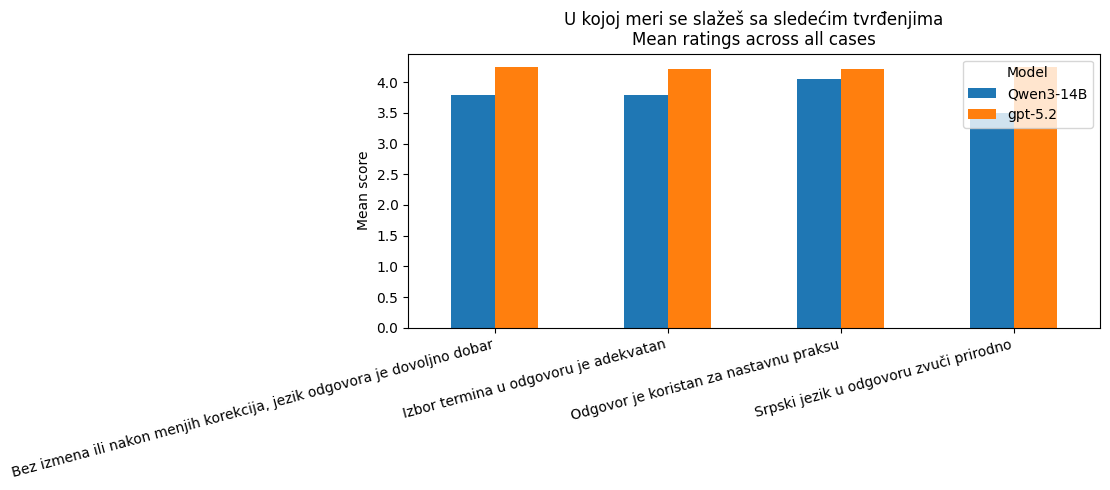

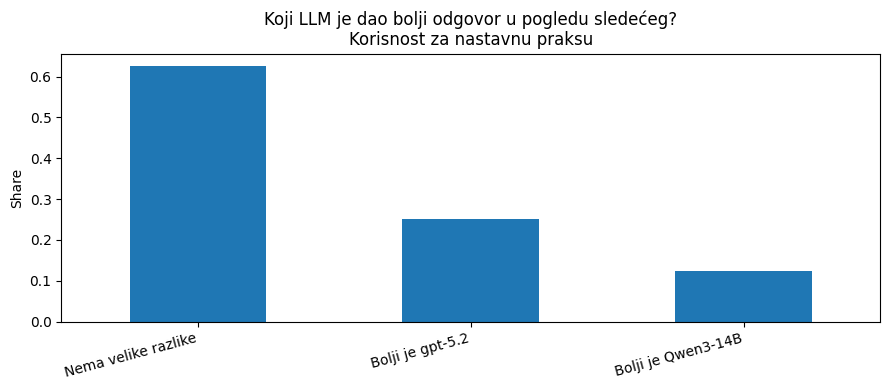

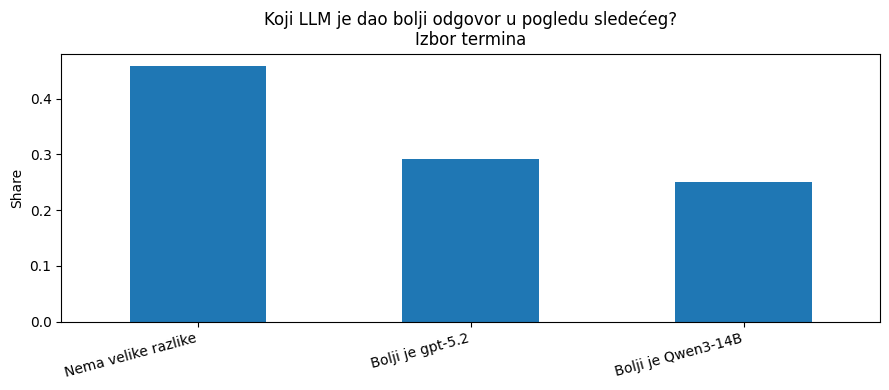

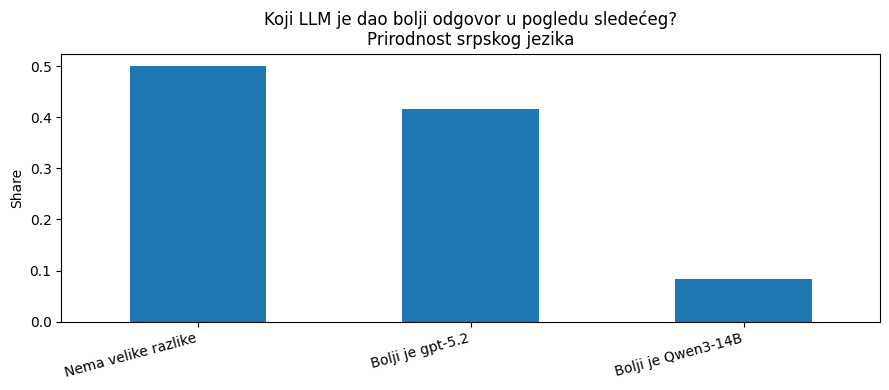

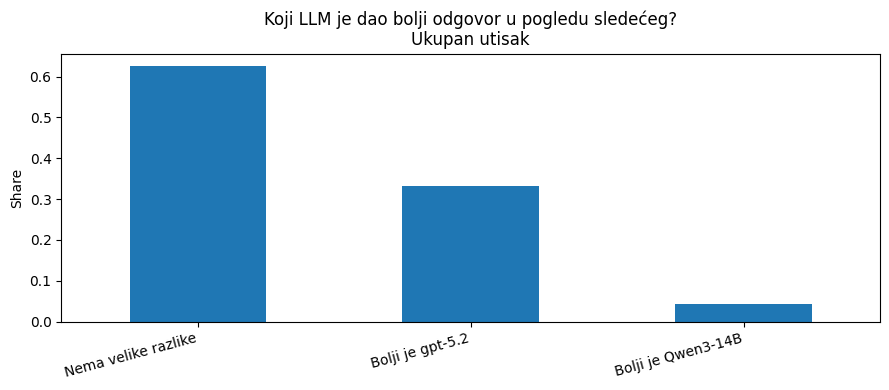

In [10]:
import matplotlib.pyplot as plt


def get_question_choice_labels(question_id: str) -> list[str]:
    labels: list[str] = []
    for page in survey_definition.get("pages", []):
        for element in page.get("elements", []):
            element_name = element.get("name")
            if not element_name or "__q" not in element_name:
                continue
            parsed = parse_question_key(element_name)
            if parsed["question_id"] != question_id:
                continue
            for column in element.get("columns", []):
                column_value = str(column.get("value", ""))
                column_text = str(column.get("text", column_value))
                normalized = normalize_choice_label(column_value, column_text)
                if normalized not in labels:
                    labels.append(normalized)
            if labels:
                return labels
    return labels


q1_means = numeric_stats[numeric_stats["question_id"] == "q1"].copy()
if not q1_means.empty:
    q1_title = q1_means["question_title"].iloc[0]
    q1_plot = q1_means.pivot(index="row_label", columns="model", values="mean")
    ax = q1_plot.plot(kind="bar", figsize=(11, 5), title=f"{q1_title}\nMean ratings across all cases")
    ax.set_xlabel("")
    ax.set_ylabel("Mean score")
    ax.legend(title="Model")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()

q4_shares = choice_stats[choice_stats["question_id"] == "q4"].copy()
if not q4_shares.empty:
    q4_title = q4_shares["question_title"].iloc[0]
    expected_q4_labels = get_question_choice_labels("q4")
    for _, row_frame in q4_shares.groupby("row_label", sort=False):
        row_label = row_frame["row_label"].iloc[0]
        plot_data = row_frame.set_index("choice_label")["share"]
        plot_data = plot_data.reindex(expected_q4_labels, fill_value=0)
        ax = plot_data.plot(kind="bar", figsize=(9, 4), title=f"{q4_title}\n{row_label}")
        ax.set_xlabel("")
        ax.set_ylabel("Share")
        plt.xticks(rotation=15, ha="right")
        plt.tight_layout()
        plt.show()